<a href="https://colab.research.google.com/github/Knguyen351/Data-Mining-Project/blob/main/DataMining_Project_Spring_2026_Alzheimer's_Disease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Mining Project Template (GitHub + Colab)
## Your Name: Kevin Nguyen
## Date: 4/10/2026
## Project Title: Data-Mining-Project

## Project workflow
This notebook follows an industry-style analytics workflow:

1. **Problem Framing & Data Acquisition**
2. **Exploratory Data Analysis (EDA) & Data Preparation**
3. **Model Development, Evaluation & Business Interpretation**

## GitHub + Colab workflow
1. Create a **new GitHub repository** for your project.
2. Upload this notebook to your repository.
3. In GitHub, open the notebook in **Google Colab**.
4. Commit changes to GitHub as you work.
5. Submit your GitHub repository link when requested.

## Project requirements
- Use a **classification dataset**
- Use **Random Forest** as one of your main models
- Use **Google Colab**
- Include **visualization, preparation, modeling, and interpretation**
- Explain results in a way a manager or stakeholder could understand


In [1]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# AutoViz
!pip install autoviz -q
from autoviz.AutoViz_Class import AutoViz_Class

# scikit-learn tools (Colab-friendly replacement for PyCaret)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report, cohen_kappa_score

# Models to compare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.5/67.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 36.2 MB/s eta 0:00:00
Imported v0.1.905. Please call AutoViz in this sequence:
    AV = AutoViz_Class()
    %matplotlib inline
    dfte = AV.AutoViz(filename, sep=',', depVar='', dfte=None, header=0, verbose=1, lowess=False,
               chart_format='svg',max_rows_analyzed=150000,max_cols_analyzed=30, save_plot_dir=None)


# Deliverable 1: Problem Framing & Data Acquisition

## What to include in this markdown cell

- What problem are you trying to solve? Predicttion of Alzheimer's Disease
- What is the **target variable**? Predictor
- What organization, industry, or domain could use this model? Healthcare
- Why does this problem matter? This disease has no cure
- Where did the dataset come from? Kaggle
- Why did you choose this dataset? Enough info to learn and predict



## Data loading options

Choose **one** of the options below:
- load a CSV from GitHub
- upload a CSV into Colab
- read from a direct URL

Keep your original raw data file in your GitHub repository whenever possible.


#   1. Data dictionary



In [2]:
# Import Dataset
url = "https://raw.githubusercontent.com/Knguyen351/Data-Mining-Project/refs/heads/main/alzheimers_disease_data.csv"
df = pd.read_csv(url)


df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [3]:
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid


# 2. Exploratory Data Analysis (EDA) & Data Preparation



The dataset is unbalance
There is a total of 2049 records out those are %65 are no Alzheimer's

In [4]:
df.value_counts("Diagnosis")

,count
Diagnosis,
0,1389
1,760


In [5]:
# Basic data inspection
print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)



Shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PatientID,2149.0,NaN,NaN,NaN,5825.0,620.507185,4751.0,5288.0,5825.0,6362.0,6899.0
Age,2149.0,NaN,NaN,NaN,74.908795,8.990221,60.0,67.0,75.0,83.0,90.0
Gender,2149.0,NaN,NaN,NaN,0.506282,0.500077,0.0,0.0,1.0,1.0,1.0
Ethnicity,2149.0,NaN,NaN,NaN,0.697534,0.996128,0.0,0.0,0.0,1.0,3.0
EducationLevel,2149.0,NaN,NaN,NaN,1.286645,0.904527,0.0,1.0,1.0,2.0,3.0
BMI,2149.0,NaN,NaN,NaN,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767
Smoking,2149.0,NaN,NaN,NaN,0.288506,0.453173,0.0,0.0,0.0,1.0,1.0
AlcoholConsumption,2149.0,NaN,NaN,NaN,10.039442,5.75791,0.002003,5.13981,9.934412,15.157931,19.989293
PhysicalActivity,2149.0,NaN,NaN,NaN,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429
DietQuality,2149.0,NaN,NaN,NaN,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346


In [6]:
# Missing values summary
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
display(missing_summary)


,0


In [7]:
# TODO: Replace with your actual target column name
target = "Diagnosis"

# Class balance
display(df[target].value_counts(dropna=False))
display(df[target].value_counts(normalize=True, dropna=False))


,count
Diagnosis,
0,1389
1,760


,proportion
Diagnosis,
0,0.646347
1,0.353653


## 2.1 AutoViz integration

AutoViz is useful for fast exploratory analysis. It can generate many plots at once.

**Important for Colab:** after AutoViz runs, use `plt.close('all')` before creating your own plots later in the notebook. This helps prevent old figures from appearing unexpectedly.


In [8]:
# Install and run AutoViz in Colab if needed
# You may comment this out if AutoViz is already installed in your runtime

# !pip install autoviz

from autoviz.AutoViz_Class import AutoViz_Class
AV = AutoViz_Class()


In [9]:
# AutoViz example
# Replace target with your real target column name before running
# dfte = AV.AutoViz(
#     "",
#     sep=",",
#     depVar=target,
#     dfte=df,
#     header=0,
#     verbose=1,
#     lowess=False,
#     chart_format="svg",
#     max_rows_analyzed=150000,
#     max_cols_analyzed=30
# )

# Clear any queued figures after AutoViz so later plots behave normally in Colab
import matplotlib.pyplot as plt
plt.close('all')


In [10]:
# Code for custom visualiations (optional)

# Example 1: target distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target)
plt.title("Target Distribution")
plt.xticks(rotation=45)
plt.show()

# Example 2: numeric histogram for one variable
# Replace 'REPLACE_NUMERIC_COLUMN' with a numeric column from your dataset
# plt.figure(figsize=(6,4))
# sns.histplot(data=df, x='REPLACE_NUMERIC_COLUMN', kde=True)
# plt.title("Distribution of REPLACE_NUMERIC_COLUMN")
# plt.show()

# Example 3: relationship to target
# Replace with columns from your dataset
# plt.figure(figsize=(7,4))
# sns.boxplot(data=df, x=target, y='REPLACE_NUMERIC_COLUMN')
# plt.title("REPLACE_NUMERIC_COLUMN by Target")
# plt.show()


### Data Preperation


#  3. Model Development, Evaluation & Interpretation



Model 1: if your goal is early prediction before diagnosis, then columns like MMSE, MemoryComplaints, FunctionalAssessment, ADL, Confusion, and Forgetfulness may be very strong because they are already symptoms/clinical indicators. Model 1 includes these features. <br><br> Model 2 removes these features.

“Can we predict Alzheimer’s diagnosis using all available clinical information?”

In [11]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -----------------------------
# 1. Remove unnecessary columns
# -----------------------------

target = "Diagnosis"

drop_cols = [
    "PatientID",
    "DoctorInCharge",
    "Diagnosis"
]

X = df.drop(columns=drop_cols)
y = df[target]

# -----------------------------
# 2. Check target balance
# -----------------------------

print("Target counts:")
print(y.value_counts())

print("\nTarget percentages:")
print(y.value_counts(normalize=True) * 100)

# -----------------------------
# 3. Train/test split
# -----------------------------
# stratify=y keeps the same 65/35 balance in train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

print("\nTraining target balance:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target balance:")
print(y_test.value_counts(normalize=True) * 100)

# -----------------------------
# 4. Build balanced Random Forest
# -----------------------------

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=123,
    class_weight="balanced"
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# -----------------------------
# 5. Evaluate model
# -----------------------------

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot()
plt.title("Balanced Random Forest Confusion Matrix")
plt.show()

# -----------------------------
# 6. Feature importance
# -----------------------------

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Plot top 15 features
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 Random Forest Feature Importances")
plt.show()

Target counts:
Diagnosis
0    1389
1     760
Name: count, dtype: int64

Target percentages:
Diagnosis
0    64.634714
1    35.365286
Name: proportion, dtype: float64

Training target balance:
Diagnosis
0    64.630599
1    35.369401
Name: proportion, dtype: float64

Testing target balance:
Diagnosis
0    64.651163
1    35.348837
Name: proportion, dtype: float64

Accuracy: 0.9441860465116279

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       278
           1       0.96      0.88      0.92       152

    accuracy                           0.94       430
   macro avg       0.95      0.93      0.94       430
weighted avg       0.94      0.94      0.94       430


Feature Importance:
            Feature            Importance
23       FunctionalAssessment   0.183154 
26                        ADL   0.159217 
22                       MMSE   0.123723 
24           MemoryComplaints   0.078599 
25         BehavioralProbl

“Can we try predict Alzheimer’s risk early before clinical testing or diagnosis?”

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# -----------------------------
# 1. Target
# -----------------------------

target = "Diagnosis"
y = df[target]

# -----------------------------
# 2. Remove ID, admin, target, and clinical testing/symptom columns
# -----------------------------

drop_cols = [
    "PatientID",
    "DoctorInCharge",
    "Diagnosis",

    # Clinical/cognitive testing
    "MMSE",
    "FunctionalAssessment",
    "ADL",

    # Symptom-based columns
    "MemoryComplaints",
    "BehavioralProblems",
    "Confusion",
    "Disorientation",
    "PersonalityChanges",
    "DifficultyCompletingTasks",
    "Forgetfulness"
]

X = df.drop(columns=drop_cols)

# -----------------------------
# 3. Feature engineering
# -----------------------------
# These are still early-risk style features, not diagnosis/testing features.

X = X.copy()

X["PulsePressure"] = X["SystolicBP"] - X["DiastolicBP"]

X["CholesterolRatio"] = X["CholesterolTotal"] / (X["CholesterolHDL"] + 1)

X["LDL_HDL_Ratio"] = X["CholesterolLDL"] / (X["CholesterolHDL"] + 1)

X["Triglyceride_HDL_Ratio"] = X["CholesterolTriglycerides"] / (X["CholesterolHDL"] + 1)

X["LifestyleScore"] = (
    X["PhysicalActivity"] +
    X["DietQuality"] +
    X["SleepQuality"]
)

X["HealthRiskScore"] = (
    X["Smoking"] +
    X["CardiovascularDisease"] +
    X["Diabetes"] +
    X["Depression"] +
    X["Hypertension"] +
    X["FamilyHistoryAlzheimers"] +
    X["HeadInjury"]
)

print("Features used:")
print(X.columns.tolist())

print("\nTarget balance:")
print(y.value_counts(normalize=True) * 100)

# -----------------------------
# 4. Train/test split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

# -----------------------------
# 5. Models to compare
# -----------------------------

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features="sqrt",
        class_weight=None,
        random_state=123,
        n_jobs=-1
    ),

    "Random Forest Balanced": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=123,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features="sqrt",
        class_weight=None,
        random_state=123,
        n_jobs=-1
    ),

    "Extra Trees Balanced": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=123,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=2,
        random_state=123
    ),

    "Hist Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=150,
        learning_rate=0.05,
        max_leaf_nodes=15,
        random_state=123
    ),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=123
        ))
    ])
}

# -----------------------------
# 6. Train models and tune threshold for best accuracy
# -----------------------------

results = []
best_model = None
best_model_name = None
best_accuracy = 0
best_threshold = 0.50
best_y_pred = None
best_y_prob = None

thresholds = np.arange(0.30, 0.71, 0.01)

for name, model in models.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    model_auc = roc_auc_score(y_test, y_prob)

    local_best_accuracy = 0
    local_best_threshold = 0.50
    local_best_pred = None

    for threshold in thresholds:
        y_pred_threshold = (y_prob >= threshold).astype(int)
        acc = accuracy_score(y_test, y_pred_threshold)

        if acc > local_best_accuracy:
            local_best_accuracy = acc
            local_best_threshold = threshold
            local_best_pred = y_pred_threshold

    report = classification_report(
        y_test,
        local_best_pred,
        output_dict=True,
        zero_division=0
    )

    class_1_recall = report["1"]["recall"]
    class_1_precision = report["1"]["precision"]
    class_1_f1 = report["1"]["f1-score"]

    results.append({
        "Model": name,
        "Best Accuracy": local_best_accuracy,
        "Best Threshold": local_best_threshold,
        "ROC_AUC": model_auc,
        "Class 1 Precision": class_1_precision,
        "Class 1 Recall": class_1_recall,
        "Class 1 F1": class_1_f1
    })

    print("Best Accuracy:", local_best_accuracy)
    print("Best Threshold:", local_best_threshold)
    print("ROC-AUC:", model_auc)
    print(classification_report(y_test, local_best_pred, zero_division=0))

    if local_best_accuracy > best_accuracy:
        best_accuracy = local_best_accuracy
        best_threshold = local_best_threshold
        best_model = model
        best_model_name = name
        best_y_pred = local_best_pred
        best_y_prob = y_prob

# -----------------------------
# 7. Results table
# -----------------------------

results_df = pd.DataFrame(results).sort_values(by="Best Accuracy", ascending=False)

print("\nFinal Model Comparison:")
print(results_df)

# -----------------------------
# 8. Best model confusion matrix
# -----------------------------

print("\nBest Model:", best_model_name)
print("Best Accuracy:", best_accuracy)
print("Best Threshold:", best_threshold)
print("ROC-AUC:", roc_auc_score(y_test, best_y_prob))

print("\nBest Model Classification Report:")
print(classification_report(y_test, best_y_pred, zero_division=0))

cm = confusion_matrix(y_test, best_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot()
plt.title(f"Best Early-Risk Model: {best_model_name}")
plt.show()

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# -----------------------------
# 1. Target
# -----------------------------
target = "Diagnosis"
y = df[target]

# -----------------------------
# 2. Columns to remove for EARLY-RISK model
# -----------------------------
base_drop_cols = [
    "PatientID",
    "DoctorInCharge",
    "Diagnosis"
]

clinical_assessment_cols = [
    "MMSE",
    "FunctionalAssessment",
    "MemoryComplaints",
    "BehavioralProblems",
    "ADL",
    "Confusion",
    "Disorientation",
    "PersonalityChanges",
    "DifficultyCompletingTasks",
    "Forgetfulness"
]

early_drop_cols = base_drop_cols + clinical_assessment_cols

# Early-risk features only
X_early = df.drop(columns=early_drop_cols)

# -----------------------------
# 3. Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_early,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

# -----------------------------
# 4. Train Random Forest
# -----------------------------
early_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=123,
    n_jobs=-1
)

early_rf.fit(X_train, y_train)

# -----------------------------
# 5. Accuracy (optional)
# -----------------------------
accuracy = early_rf.score(X_test, y_test)
print("Early-Risk Model Accuracy:", accuracy)

# -----------------------------
# 6. Feature Importance Ranking
# -----------------------------
feature_importance = pd.DataFrame({
    "Feature": X_early.columns,
    "Importance": early_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance)

In [26]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# -----------------------------
# 1. Target
# -----------------------------

target = "Diagnosis"
y = df[target]

# -----------------------------
# 2. Remove only formal clinical testing columns
# -----------------------------

drop_cols = [
    "PatientID",
    "DoctorInCharge",
    "Diagnosis",
    "MMSE",
    "FunctionalAssessment",
    "ADL"
]

X = df.drop(columns=drop_cols).copy()

# -----------------------------
# 3. Feature engineering
# -----------------------------

X["PulsePressure"] = X["SystolicBP"] - X["DiastolicBP"]
X["CholesterolRatio"] = X["CholesterolTotal"] / (X["CholesterolHDL"] + 1)
X["LDL_HDL_Ratio"] = X["CholesterolLDL"] / (X["CholesterolHDL"] + 1)
X["Triglyceride_HDL_Ratio"] = X["CholesterolTriglycerides"] / (X["CholesterolHDL"] + 1)

X["LifestyleScore"] = (
    X["PhysicalActivity"] +
    X["DietQuality"] +
    X["SleepQuality"]
)

X["HealthRiskScore"] = (
    X["Smoking"] +
    X["CardiovascularDisease"] +
    X["Diabetes"] +
    X["Depression"] +
    X["Hypertension"] +
    X["FamilyHistoryAlzheimers"] +
    X["HeadInjury"]
)

X["SymptomScore"] = (
    X["MemoryComplaints"] +
    X["BehavioralProblems"] +
    X["Confusion"] +
    X["Disorientation"] +
    X["PersonalityChanges"] +
    X["DifficultyCompletingTasks"] +
    X["Forgetfulness"]
)

# -----------------------------
# 4. Train/test split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=123,
    stratify=y
)

# -----------------------------
# 5. Stronger Random Forest
# -----------------------------

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=123,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# -----------------------------
# 6. Predict probabilities
# -----------------------------

y_prob = rf_model.predict_proba(X_test)[:, 1]

# -----------------------------
# 7. Tune threshold for highest accuracy
# -----------------------------

thresholds = np.arange(0.30, 0.71, 0.01)

best_accuracy = 0
best_threshold = 0.50
best_pred = None

for threshold in thresholds:
    y_pred_temp = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred_temp)

    if acc > best_accuracy:
        best_accuracy = acc
        best_threshold = threshold
        best_pred = y_pred_temp

# -----------------------------
# 8. Results
# -----------------------------

print("Best Threshold:", best_threshold)
print("Best Accuracy:", best_accuracy)
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, best_pred, zero_division=0))

# -----------------------------
# 9. Feature importance
# -----------------------------

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance)

Best Threshold: 0.4000000000000001
Best Accuracy: 0.686046511627907
ROC-AUC: 0.6507004922377886

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.76      0.76       278
           1       0.56      0.55      0.55       152

    accuracy                           0.69       430
   macro avg       0.66      0.65      0.65       430
weighted avg       0.68      0.69      0.69       430


Feature Importance:
            Feature            Importance
22           MemoryComplaints   0.077871 
23         BehavioralProblems   0.050621 
9                SleepQuality   0.049107 
4                         BMI   0.046778 
6          AlcoholConsumption   0.046084 
21   CholesterolTriglycerides   0.045881 
7            PhysicalActivity   0.045062 
29              PulsePressure   0.044964 
31              LDL_HDL_Ratio   0.044699 
33             LifestyleScore   0.044648 
8                 DietQuality   0.044576 
18           CholesterolTota

The early-risk model had about 65% accuracy, but the classification report showed that it mainly predicted the majority class. The recall for Alzheimer’s cases was very low, meaning the model did not identify most positive diagnosis cases. This suggests that lifestyle and general health variables alone are not strong enough to accurately predict Alzheimer’s diagnosis in this dataset. The model improved conceptually when clinical assessment variables were included, showing that cognitive and functional assessment features are much stronger predictors. (in your own words)

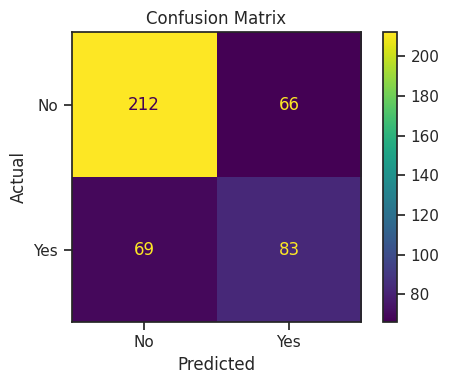

In [33]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use best_pred from your threshold-tuned model
cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(5, 4))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot(ax=ax, values_format="d")

ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## Feature importance

Feature importance helps us see which inputs influenced the Random Forest most.

Be careful:
- importance does **not** prove causation
- importance can be split across multiple one-hot encoded columns
- importance tells us what mattered to the model, not necessarily what matters in the real world


## Interpretation prompts

Write short answers below:
- How well did the model perform?
- Which class was easier or harder to predict?
- Which variables seemed most important?
- Where did the model make mistakes?
- How could this model be used by a real organization?
- What would you improve next?


### Student interpretation summary
Replace this section with your final written interpretation.
